# End-to-End Property Prediction with GSGE

This tutorial demonstrates a complete machine learning pipeline using GSGE fragment embeddings for molecular property prediction.

## Overview

You will learn how to:
1. Build a custom vocabulary from your dataset
2. Train a Graph Autoencoder (GAE) to learn fragment embeddings
3. Extract embeddings for all fragments
4. Create molecular-level features from fragment embeddings
5. Train a property prediction model
6. Evaluate and make predictions

## Prerequisites

- GSGE installed with all dependencies
- Basic understanding of machine learning
- GPU recommended (but CPU works)

## 1. Setup and Imports

In [1]:
# GSGE imports
from GSGE import GSGE, GS_Vocab, GSGE_Corpus, CUSTOM_fragment_mol

# Machine learning imports
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns

# PyTorch for GAE training
import torch

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Check device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

print("[OK] Imports successful")

Using device: cuda
[OK] Imports successful


## 2. Load Dataset

**Note:** This tutorial uses peptide examples because the `CUSTOM_fragment_mol` fragmentation function is designed for cyclic peptides (it cuts ring bonds, amide bonds, and disulfide bonds).

For small molecules (drugs, organic compounds), you would need a different fragmentation function or use a pre-trained vocabulary.

The example data here demonstrates the pipeline. Replace with your own peptide dataset.

In [2]:
# Example: Create a sample dataset with peptides
# In practice, load your data from a file

# Sample peptide SMILES (replace with your data)
# These are cyclic peptide-like molecules that work well with CUSTOM_fragment_mol
smiles_list = [
    'C1CC(NC(=O)C(N)CSSC(N)C(=O)NCC(=O)O)NC(=O)C(NC(=O)C1)C(=O)O',  # Cyclic peptide with disulfide
    'C1CC(NC(=O)C(N)C(=O)NCC(=O)O)NC(=O)C(NC(=O)C1)C(=O)O',  # Cyclic peptide
    'C1CCC(NC(=O)C(N)C(=O)NCC(=O)O)NC(=O)C1',  # Cyclic peptide fragment
    'C1CC(NC(=O)C(N)C(=O)NCC(=O)O)NC(=O)C1C(=O)O',  # Cyclic peptide with carboxyl
    'CSSC(N)C(=O)NCC(=O)O',  # Disulfide bridge fragment
    'CC(NC(=O)C(N)C(=O)NCC(=O)O)C(=O)O',  # Linear peptide
    'C1C(NC(=O)C(N)C(=O)O)CC(NC(=O)C1)C(=O)O',  # Another cyclic peptide
    'NC(CC(=O)O)C(=O)NCCC(=O)O',  # Short linear peptide
    'C1CCC(NC(=O)C(N)CSSC(N)C(=O)O)NC(=O)C1',  # Cyclic with disulfide
    'CC(C)NC(=O)C(N)C(=O)NCC(=O)O',  # Branched peptide
    # Add more peptides...
]

# Sample properties (replace with your data)
# Example: LogP values or binding affinity
properties = np.array([
    -1.2,  # Peptide 1
    -0.8,  # Peptide 2
    -0.5,  # Peptide 3
    -0.9,  # Peptide 4
    -1.5,  # Peptide 5
    -1.1,  # Peptide 6
    -0.7,  # Peptide 7
    -1.3,  # Peptide 8
    -0.6,  # Peptide 9
    -1.0,  # Peptide 10
    # Add more values...
])

print(f"Dataset size: {len(smiles_list)} molecules")
print(f"Property range: [{properties.min():.2f}, {properties.max():.2f}]")

# For a real dataset, load from CSV:
# df = pd.read_csv('your_data.csv')
# smiles_list = df['SMILES'].tolist()
# properties = df['property'].values

Dataset size: 10 molecules
Property range: [-1.50, -0.50]


## 3. Split Data

Split into training and test sets.

In [3]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    smiles_list, properties, test_size=0.2, random_state=42
)

print(f"Training set: {len(X_train)} molecules")
print(f"Test set: {len(X_test)} molecules")

Training set: 8 molecules
Test set: 2 molecules


## 4. Build Vocabulary

Create a custom vocabulary tailored to your chemical space.

**Important Parameters:**
- `n_limit`: Minimum occurrence count for fragment cores. Should be much smaller than your dataset size. For small datasets (<100 molecules), use `n_limit=1`.
- `target`: Target vocabulary size after diversity selection.
- `MIN_SIZE`/`MAX_SIZE`: Fragment size range in atoms.

In [4]:
# Build corpus (for GAE training)
print("Building corpus...")
corpus = GSGE_Corpus()
corpus.build_corpus(
    X_train,
    min_size=1,
    max_size=15,
    fragment_mol_fn=CUSTOM_fragment_mol,
    convert=True,
    fragmented=False  # Keep all fragments for training
)
# Note: Saving is optional - we'll pass the objects directly to GSGE
# corpus.save_GSGE_corpus('tutorial_corpus', meta_info='Property prediction tutorial')

print(f"[OK] Corpus: {corpus.num_fragments} fragments")

# Build vocabulary (for representation)
print("\nBuilding vocabulary...")
vocab = GS_Vocab()
vocab.build_vocab(
    m_set=X_train,
    convert=True,
    n_limit=1,  # IMPORTANT: Must be much smaller than dataset size!
    target=200,
    fragment_mol_fn=CUSTOM_fragment_mol
)
# Note: Saving is optional - we'll pass the objects directly to GSGE
# vocab.save_GS_vocab('tutorial_vocab', meta_info='Property prediction tutorial')

print(f"[OK] Vocabulary: {vocab.num_fragments} fragments")

Building corpus...


100%|██████████| 17/17 [00:00<00:00, 352.63it/s]


[OK] Corpus: 18 fragments

Building vocabulary...


100%|██████████| 10/10 [00:00<00:00, 334.48it/s]

[OK] Vocabulary: 10 fragments


## 5. Create GSGE Object

Initialize GSGE with vocabulary and corpus.

In [5]:
# Create GSGE instance - pass vocab and corpus objects directly
# (This avoids file I/O issues and uses the objects we just built)
gsge = GSGE(GS_vocab=vocab, GSGE_corpus=corpus)

# IMPORTANT: Add single elements for full coverage
gsge.add_all_single_elements()

# Add vocab fragments to corpus (for GAE training)
# This method automatically uses the vocab_manager internally
gsge.add_GS_vocab_to_GSGE_corpus()

print(f"[OK] GSGE initialized")
print(f"  - Vocab fragments: {gsge.vocab_manager.GS_vocab.num_fragments}")
print(f"  - Corpus fragments: {gsge.vocab_manager.GSGE_corpus.num_fragments}")

Added single elements to GS_vocab
Added single elements to GSGE_corpus
[OK] GSGE initialized
  - Vocab fragments: 69
  - Corpus fragments: 77


## 6. Train Graph Autoencoder

Train the GAE to learn fragment embeddings.

**Note:** This step can take 1-2 hours on GPU, 4-6 hours on CPU.
For faster testing, reduce `num_epochs` to 10-20.

In [6]:
# Set up encoder and decoder before training
# The default models will be used if no arguments provided
print("Setting up encoder and decoder...")
gsge.set_encoder()  # Creates default AttentiveFP encoder
print(f"  Encoder set: {gsge.gae_trainer.store_modules.modules['encoder'] is not None}")

gsge.set_decoder()  # Creates default GraphDecoder
print(f"  Decoder set: {gsge.gae_trainer.store_modules.modules['decoder'] is not None}")

# Train GAE
# For quick testing, use num_epochs=10
# For production use, use num_epochs=100-300

checkpoint_dir = 'tutorial_checkpoints'

print("\nStarting GAE training...")
gsge.train_GSGE_Auto_Encoder(
    num_epochs=50,  # Increase to 100-300 for better results
    checkpoint_interval=10,
    checkpoint_dir=checkpoint_dir,
    batch_size=32,  # Reduce if OOM
    device=device
)

print(f"\n[OK] GAE training complete!")
print(f"  Checkpoints saved to: {checkpoint_dir}")

Setting up encoder and decoder...
  Encoder set: True
  Decoder set: True

Starting GAE training...
Splitting data...
Train size: 759, Test size: 8
Converting SMILES to graphs for training data...
Converting SMILES to graphs for validation data...
Starting training from scratch


C:\Users\Admin\miniconda3\envs\gsge-dev\Lib\site-packages\sklearn\metrics\_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
C:\Users\Admin\miniconda3\envs\gsge-dev\Lib\site-packages\sklearn\metrics\_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


Epoch [1/50] ------------------------------------- Train
  Train Atom Loss: 38.0482, Train Edge Loss: 15.0316, Train Total Loss: 53.0798
  Train atom_accuracy: 0.5727, Train atom_f1: 0.1048, Train balanced_atom_acc: 0.1200, Train atom_num_r2: 0.4099
  Train edge_type_accuracy: 0.8808, Train edge_type_f1: 0.2108, Train balanced_edge_type_acc: 0.5267, Train edge_num_r2: 0.4965
  Train adj_accuracy: 0.7766, Train adj_f1: 0.7669, Train balanced_adj_acc: 0.7854



C:\Users\Admin\miniconda3\envs\gsge-dev\Lib\site-packages\sklearn\metrics\_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


Epoch [1/50] ------------------------------------- Val
  Val Atom Loss: 1.4795, Val Edge Loss: 1.5653, Val Total Loss: 3.0448
  Val atom_accuracy: 0.4909, Val atom_f1: 0.3880, Val balanced_atom_acc: 0.4580, Val atom_num_r2: 0.9917
  Val edge_type_accuracy: 0.7234, Val edge_type_f1: 0.3261, Val balanced_edge_type_acc: 0.4898, Val edge_num_r2: 0.9969
  Val adj_accuracy: 0.7297, Val adj_f1: 0.6861, Val balanced_adj_acc: 0.7206

Checkpoint saved at tutorial_checkpoints\checkpoint_epoch_0.pth
Epoch [2/50] ------------------------------------- Train
  Train Atom Loss: 20.4835, Train Edge Loss: 2.6910, Train Total Loss: 23.1745
  Train atom_accuracy: 0.7228, Train atom_f1: 0.1924, Train balanced_atom_acc: 0.2110, Train atom_num_r2: 0.9888
  Train edge_type_accuracy: 0.9539, Train edge_type_f1: 0.6617, Train balanced_edge_type_acc: 0.6256, Train edge_num_r2: 0.9890
  Train adj_accuracy: 0.9042, Train adj_f1: 0.8984, Train balanced_adj_acc: 0.9143

Epoch [2/50] ---------------------------------

...

C:\Users\Admin\miniconda3\envs\gsge-dev\Lib\site-packages\sklearn\metrics\_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
C:\Users\Admin\miniconda3\envs\gsge-dev\Lib\site-packages\sklearn\metrics\_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


Epoch [50/50] ------------------------------------- Train
  Train Atom Loss: 0.0159, Train Edge Loss: 0.0143, Train Total Loss: 0.0302
  Train atom_accuracy: 1.0000, Train atom_f1: 1.0000, Train balanced_atom_acc: 1.0000, Train atom_num_r2: 0.9994
  Train edge_type_accuracy: 1.0000, Train edge_type_f1: 1.0000, Train balanced_edge_type_acc: 1.0000, Train edge_num_r2: 0.9995
  Train adj_accuracy: 1.0000, Train adj_f1: 1.0000, Train balanced_adj_acc: 1.0000

Epoch [50/50] ------------------------------------- Val
  Val Atom Loss: 4.5816, Val Edge Loss: 4.5532, Val Total Loss: 9.1348
  Val atom_accuracy: 0.6364, Val atom_f1: 0.4968, Val balanced_atom_acc: 0.6238, Val atom_num_r2: 0.9990
  Val edge_type_accuracy: 0.8723, Val edge_type_f1: 0.5299, Val balanced_edge_type_acc: 0.7515, Val edge_num_r2: 0.9988
  Val adj_accuracy: 0.8054, Val adj_f1: 0.7433, Val balanced_adj_acc: 0.7433



C:\Users\Admin\miniconda3\envs\gsge-dev\Lib\site-packages\sklearn\metrics\_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
C:\Users\Admin\miniconda3\envs\gsge-dev\Lib\site-packages\sklearn\metrics\_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


Epoch [51/50] ------------------------------------- Train
  Train Atom Loss: 0.0137, Train Edge Loss: 0.0117, Train Total Loss: 0.0254
  Train atom_accuracy: 1.0000, Train atom_f1: 1.0000, Train balanced_atom_acc: 1.0000, Train atom_num_r2: 0.9997
  Train edge_type_accuracy: 1.0000, Train edge_type_f1: 1.0000, Train balanced_edge_type_acc: 1.0000, Train edge_num_r2: 0.9998
  Train adj_accuracy: 1.0000, Train adj_f1: 1.0000, Train balanced_adj_acc: 1.0000

Epoch [51/50] ------------------------------------- Val
  Val Atom Loss: 4.6629, Val Edge Loss: 4.5835, Val Total Loss: 9.2464
  Val atom_accuracy: 0.6364, Val atom_f1: 0.4968, Val balanced_atom_acc: 0.6238, Val atom_num_r2: 0.9990
  Val edge_type_accuracy: 0.8723, Val edge_type_f1: 0.5299, Val balanced_edge_type_acc: 0.7515, Val edge_num_r2: 0.9986
  Val adj_accuracy: 0.8054, Val adj_f1: 0.7433, Val balanced_adj_acc: 0.7433

Checkpoint saved at tutorial_checkpoints\checkpoint_epoch_50.pth

[OK] GAE training complete!
  Checkpoints sa

C:\Users\Admin\miniconda3\envs\gsge-dev\Lib\site-packages\sklearn\metrics\_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
C:\Users\Admin\miniconda3\envs\gsge-dev\Lib\site-packages\sklearn\metrics\_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


## 7. Generate Fragment Embeddings

Load the trained model and generate embeddings for all fragments.

In [7]:
# Load best checkpoint and generate embeddings
import os

# Find the latest checkpoint
checkpoints = [f for f in os.listdir(checkpoint_dir) if f.endswith('.pth')]
latest_checkpoint = sorted(checkpoints)[-1]
checkpoint_path = os.path.join(checkpoint_dir, latest_checkpoint)

print(f"Loading checkpoint: {checkpoint_path}")

# Load encoder weights and generate embeddings
# Note: set_encoder() is optional - a default AttentiveFP encoder was created during init
gsge.load_GAE_weights(checkpoint_path)
gsge.make_GS_fragment_embedding_dict()

# Get embeddings
embeddings = gsge.get_fragment_embeddings()
print(f"\n[OK] Embeddings generated")
print(f"  Shape: {embeddings.shape}")
print(f"  (vocab_size, embedding_dim)")

Loading checkpoint: tutorial_checkpoints\checkpoint_epoch_50.pth
Encoder weights loaded


100%|██████████| 2/2 [00:00<00:00, 78.46it/s]


[OK] Embeddings generated
  Shape: torch.Size([69, 128])
  (vocab_size, embedding_dim)


## 8. Create Molecular Features

Convert fragment embeddings to molecular-level features using pooling.

In [8]:
def get_molecular_features(smiles, gsge, pooling='mean'):
    """
    Get molecular features from fragment embeddings.
    
    Args:
        smiles: SMILES string
        gsge: GSGE instance with embeddings
        pooling: 'mean', 'max', or 'sum'
    
    Returns:
        Molecular feature vector
    """
    # Tokenize molecule
    tokens = gsge.preprocess_from_SMILES(smiles)
    
    # Get fragment tokens only
    frag_tokens = [t for t in tokens if t.startswith('GS_frag_')]
    
    if not frag_tokens:
        # Return zeros if no fragments
        return np.zeros(gsge.get_fragment_embeddings().shape[1])
    
    # Get fragment IDs from vocab_manager (token-to-ID mapping)
    token_dict = gsge.vocab_manager.GSGE_vocab
    frag_ids = [token_dict[t] for t in frag_tokens if t in token_dict]
    
    if not frag_ids:
        return np.zeros(gsge.get_fragment_embeddings().shape[1])
    
    # Get fragment embeddings
    frag_embeddings = gsge.get_fragment_embeddings()
    
    # Filter to valid embeddings only (handle cases where encoding failed)
    valid_embeddings = []
    for frag_id in frag_ids:
        if frag_id < len(frag_embeddings):
            emb = frag_embeddings[frag_id]
            # Convert to numpy array if it's a tensor
            if hasattr(emb, 'detach'):  # PyTorch tensor
                emb = emb.detach().cpu().numpy()
            elif hasattr(emb, 'tolist'):  # Already numpy array
                emb = np.asarray(emb)
            
            # Check if embedding is valid (not None and finite)
            if emb is not None and np.all(np.isfinite(emb)):
                valid_embeddings.append(emb)
    
    if not valid_embeddings:
        return np.zeros(frag_embeddings.shape[1])
    
    # Stack embeddings for pooling
    mol_embeddings = np.stack(valid_embeddings, axis=0)
    
    # Pool embeddings
    if pooling == 'mean':
        return np.mean(mol_embeddings, axis=0)
    elif pooling == 'max':
        return np.max(mol_embeddings, axis=0)
    elif pooling == 'sum':
        return np.sum(mol_embeddings, axis=0)
    else:
        raise ValueError(f"Unknown pooling: {pooling}")

# Create features for all molecules
print("Creating molecular features...")
X_train_features = np.array([get_molecular_features(s, gsge) for s in X_train])
X_test_features = np.array([get_molecular_features(s, gsge) for s in X_test])

print(f"[OK] Features created")
print(f"  Train: {X_train_features.shape}")
print(f"  Test: {X_test_features.shape}")

Creating molecular features...
[OK] Features created
  Train: (8, 128)
  Test: (2, 128)


## 9. Train Property Predictor

Train a machine learning model on the learned features.

In [9]:
# Train Random Forest regressor
print("Training Random Forest...")
model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train_features, y_train)

print("[OK] Model trained")

Training Random Forest...
[OK] Model trained


## 10. Evaluate Model

Evaluate on test set and compute metrics.

In [10]:
# Make predictions
y_pred = model.predict(X_test_features)

# Compute metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Test Set Results:")
print(f"  MSE:  {mse:.4f}")
print(f"  RMSE: {rmse:.4f}")
print(f"  MAE:  {mae:.4f}")
print(f"  R^2:   {r2:.4f}")

Test Set Results:
  MSE:  0.0883
  RMSE: 0.2972
  MAE:  0.2960
  R^2:   -7.8345


## 11. Visualize Results

Plot predictions vs actual values.

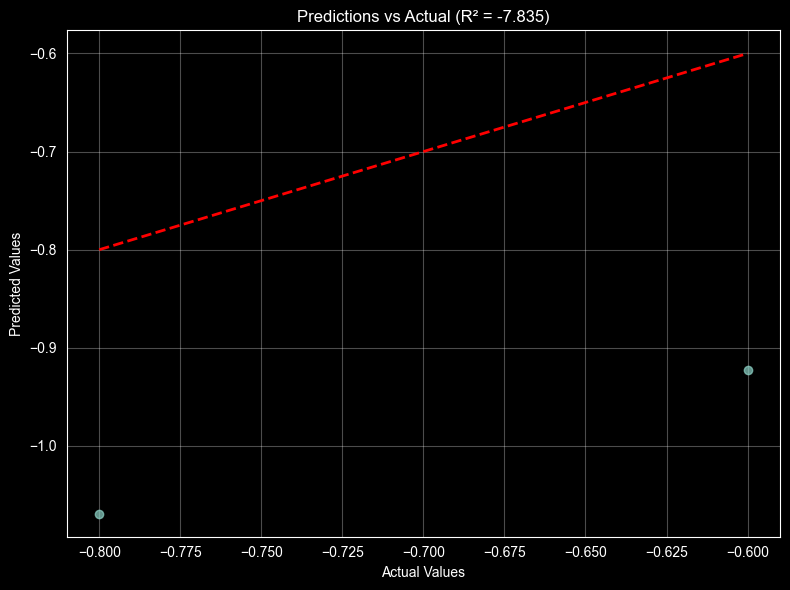

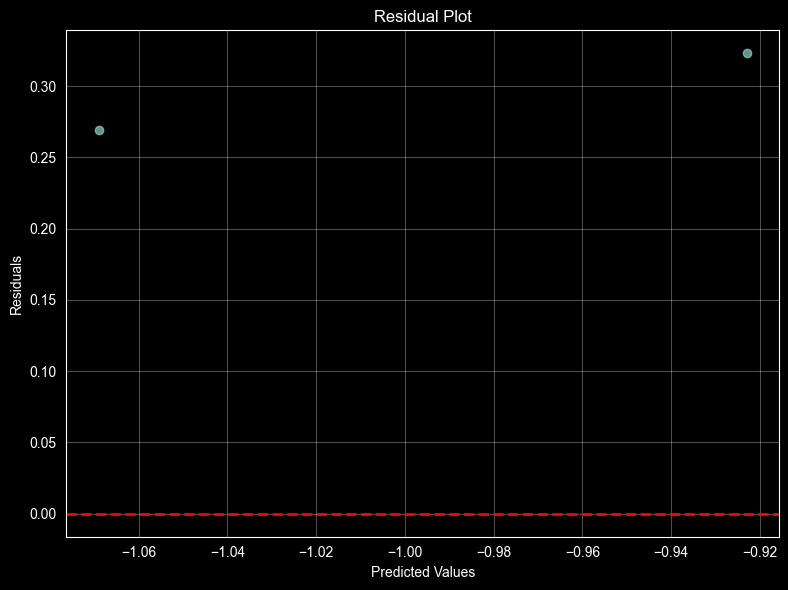

In [11]:
# Plot predictions vs actual
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title(f'Predictions vs Actual (R^2 = {r2:.3f})')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Residual plot
residuals = y_test - y_pred
plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals, alpha=0.7)
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 12. Cross-Validation

Perform cross-validation to assess model stability.

In [12]:
# Cross-validation
# Note: With small datasets, reduce cv folds to avoid errors
cv_folds = min(5, len(X_train_features) // 2)  # Ensure at least 2 samples per fold
cv_folds = max(2, cv_folds)  # At least 2-fold CV
print(f"Using {cv_folds}-fold cross-validation")

cv_scores = cross_val_score(
    model, X_train_features, y_train,
    cv=cv_folds,
    scoring='r2'
)

print("Cross-Validation Results:")
print(f"  R^2 scores: {cv_scores}")
print(f"  Mean R^2:  {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")

Using 4-fold cross-validation
Cross-Validation Results:
  R^2 scores: [-18.445       -0.09324063  -1.664584    -1.1866    ]
  Mean R^2:  -5.3474 +/- 7.5833


## 13. Feature Importance

Analyze which embedding dimensions are most important.

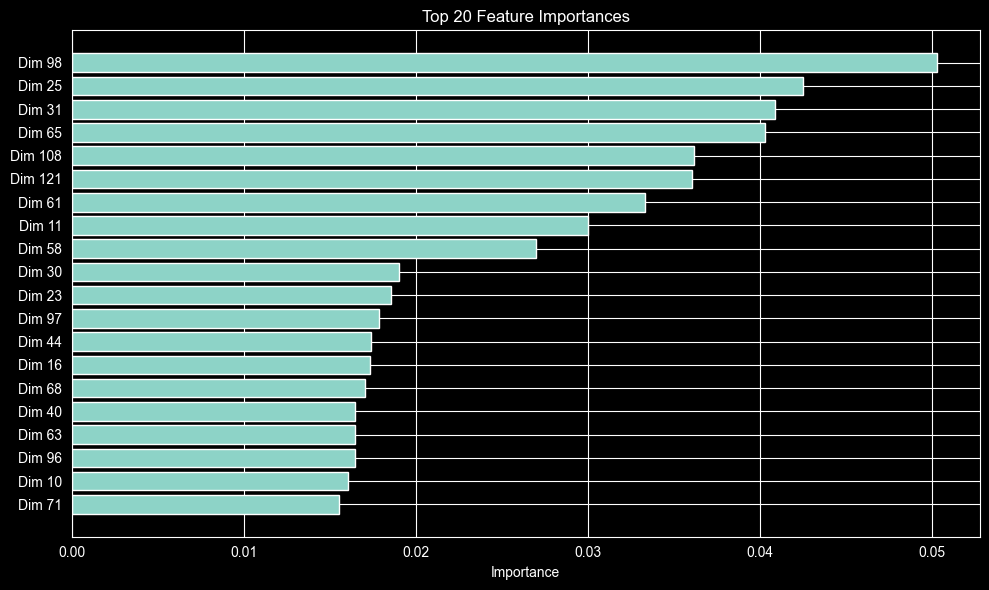

In [13]:
# Feature importance
importance = model.feature_importances_

# Plot top features
n_top = 20
top_indices = np.argsort(importance)[-n_top:]

plt.figure(figsize=(10, 6))
plt.barh(range(n_top), importance[top_indices])
plt.yticks(range(n_top), [f'Dim {i}' for i in top_indices])
plt.xlabel('Importance')
plt.title(f'Top {n_top} Feature Importances')
plt.tight_layout()
plt.show()

## 14. Predict on New Molecules

Make predictions on unseen molecules.

In [14]:
# Predict on new peptides
new_smiles = [
    'C1CCC(NC(=O)C(N)CSSC(N)C(=O)O)NC(=O)C1',  # New cyclic peptide
    'CC(C)CC(NC(=O)C(N)C(=O)O)C(=O)O',  # Linear peptide fragment
]

for smiles in new_smiles:
    features = get_molecular_features(smiles, gsge)
    prediction = model.predict([features])[0]
    print(f"{smiles}: {prediction:.4f}")

C1CCC(NC(=O)C(N)CSSC(N)C(=O)O)NC(=O)C1: -0.9230
CC(C)CC(NC(=O)C(N)C(=O)O)C(=O)O: -0.7950


## 15. Save Model and GSGE

Save everything for future use.

In [15]:
import joblib
import os

# Save predictor
model_path = 'property_predictor.pkl'
if os.path.exists(model_path):
    print(f"Note: Overwriting existing {model_path}")
joblib.dump(model, model_path)

# Save GSGE with embeddings
gsge_path = 'gsge_with_embeddings.pkl'
if os.path.exists(gsge_path):
    print(f"Note: Overwriting existing {gsge_path}")
gsge.save_gsge_data(gsge_path, meta_info='Property prediction tutorial')

print("[OK] Model and GSGE saved")
print(f"  - {model_path}")
print(f"  - {gsge_path}")

Note: Overwriting existing property_predictor.pkl
Note: Overwriting existing gsge_with_embeddings.pkl
Data saved to gsge_with_embeddings.pkl
[OK] Model and GSGE saved
  - property_predictor.pkl
  - gsge_with_embeddings.pkl


## 16. Load and Use Saved Model

Demonstrate loading the saved model for inference.

In [16]:
# Load saved model
loaded_model = joblib.load('property_predictor.pkl')

# Load saved GSGE
loaded_gsge = GSGE(GSGE_load_path='gsge_with_embeddings.pkl')

# Make prediction
test_smiles = 'C1CCC(NC(=O)C(N)C(=O)O)NC(=O)C1'  # Test peptide
features = get_molecular_features(test_smiles, loaded_gsge)
prediction = loaded_model.predict([features])[0]

print(f"Prediction for {test_smiles}: {prediction:.4f}")
print("[OK] Model loading successful")

Data loaded and restored into gsge from gsge_with_embeddings.pkl
Prediction for C1CCC(NC(=O)C(N)C(=O)O)NC(=O)C1: -0.8010
[OK] Model loading successful


## Summary

### What You Accomplished

[OK] Built a custom vocabulary from your dataset
[OK] Trained a Graph Autoencoder to learn fragment embeddings
[OK] Created molecular features from fragment embeddings
[OK] Trained a property prediction model
[OK] Evaluated model performance
[OK] Made predictions on new molecules
[OK] Saved and loaded models for deployment

### Next Steps

1. **Try different models**: XGBoost, Neural Networks, SVM
2. **Hyperparameter tuning**: Grid search or random search
3. **Combine with descriptors**: Add RDKit descriptors to embeddings
4. **Different pooling**: Try max or sum pooling instead of mean
5. **Larger dataset**: More data = better performance
6. **Transfer learning**: Use pre-trained embeddings for new tasks

### Additional Resources

- [GAE Training Tutorial](../03_GAE/README.md)
- [Using Embeddings](../04_use_embeddings/README.md)
- [Fragment Descriptors](../05_mol_frag_features/README.md)

---

**Questions?** Open an issue on [GitHub](https://github.com/CDDLeiden/GSGE/issues)